# California Housing - Feature Engineering

**DATA 4950 Week 8 Demo**

## What We Will Cover
1. Load preprocessed data
2. Create new features (ratios, bins, interactions, log transformation)
3. Encode categorical features
4. Scale numerical features
5. Feature selection
6. Save final data for modeling

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## 1. Load and Quick Prep

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 16,168 rows x 8 columns
y_train Loaded: 16,168 rows x 1 columns
X_test Loaded: 4,042 rows x 8 columns
y_test Loaded: 4,042 rows x 1 columns


In [3]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.048312,36.0,6.266871,1.233132,606.0,1.858896,34.02,-118.60
1,3.267200,32.0,5.204380,1.070560,1154.0,2.807786,38.45,-121.83
2,3.093800,6.0,4.979679,1.038503,2320.0,2.481283,35.41,-118.90
3,2.556800,18.0,6.114035,1.233132,356.0,3.122807,39.49,-121.21
4,1.981100,16.0,6.104730,1.168919,587.0,1.983108,34.19,-118.96


In [4]:
## check column types

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

Numerical (8): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Categorical (0): []


## 2. Create New Features

Feature engineering adds **domain knowledge** to help the model.  
We create features on both train and test using the **same logic**.

### 2.1 Binning — Income and House Age Groups

In [5]:
# TODO: Create Income Category

income_bins = [0, 2, 4, 6, 8, np.inf]
income_labels = [1, 2, 3, 4, 5]  # 1=Low, 2=Low-Med, 3=Med, 4=Med-High, 5=High

X_train['IncomeCategory'] =pd.cut(X_train['MedInc'], bins= income_bins,labels=income_labels)
X_test['IncomeCategory'] =pd.cut(X_test['MedInc'], bins= income_bins,labels=income_labels)

print('Income categories created:')
print(X_train['IncomeCategory'].value_counts().sort_index())

Income categories created:
IncomeCategory
1    1934
2    7887
3    4476
4    1315
5     556
Name: count, dtype: int64


In [6]:
#Create House Age Category
def categorize_age(age):
    if age <= 10:
        return 'New'
    elif age <= 30:
        return 'Medium'
    else:
        return 'Old'

X_train['AgeCategory'] = X_train['HouseAge'].apply(categorize_age)
X_test['AgeCategory'] = X_test['HouseAge'].apply(categorize_age)

print("\nAge category distribution:")
print(X_train['AgeCategory'].value_counts())


Age category distribution:
AgeCategory
Medium    7924
Old       7095
New       1149
Name: count, dtype: int64


### 2.2 Ratio Features

In [7]:
# TODO: Rooms per Person (proxy for spaciousness)
X_train['RoomsPerPerson'] = X_train['AveRooms'] / X_train['AveOccup']
X_test['RoomsPerPerson'] = X_test['AveRooms'] / X_test['AveOccup']


print('Create: RoomsPerPerson')
print(f'Mean: {X_train['RoomsPerPerson'].mean():.2f}')

Create: RoomsPerPerson
Mean: 1.93


In [8]:
# Bedroom Ratio (proportion of rooms that are bedrooms)

X_train['BedroomRatio'] = X_train['AveBedrms'] / X_train['AveRooms']
X_test['BedroomRatio'] = X_test['AveBedrms'] / X_test['AveRooms']


print('Create: BedroomRatio')
print(f'Mean: {X_train['BedroomRatio'].mean():.2f}')

Create: BedroomRatio
Mean: 0.21


### 2.3 Location-Based Features

In [9]:
# Region based on latitude
def get_region(lat):
    if lat > 38:
        return 'North'
    elif lat > 35:
        return 'Central'
    else:
        return 'South'

X_train['Region'] = X_train['Latitude'].apply(get_region)
X_test['Region'] = X_test['Latitude'].apply(get_region)

print("Region distribution:")
print(X_train['Region'].value_counts())

Region distribution:
Region
South      8855
Central    4964
North      2349
Name: count, dtype: int64


In [10]:
# Distance from major cities (San Francisco, LA)
# San Francisco: 37.7749° N, 122.4194° W
# Los Angeles: 34.0522° N, 118.2437° W

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in km between two lat/lon points."""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# Distance to San Francisco
X_train['DistToSF'] = haversine_distance(X_train['Latitude'], X_train['Longitude'], 37.7749, -122.4194)
X_test['DistToSF'] = haversine_distance(X_test['Latitude'], X_test['Longitude'], 37.7749, -122.4194)

# Distance to LA
X_train['DistToLA'] = haversine_distance(X_train['Latitude'], X_train['Longitude'], 34.0522, -118.2437)
X_test['DistToLA'] = haversine_distance(X_test['Latitude'], X_test['Longitude'], 34.0522, -118.2437)

print("Distance features created!")
print(f"Avg distance to SF: {X_train['DistToSF'].mean():.1f} km")
print(f"Avg distance to LA: {X_train['DistToLA'].mean():.1f} km")

Distance features created!
Avg distance to SF: 386.3 km
Avg distance to LA: 268.9 km


### 3. Encode Categorical Features

Convert categorical columns to numbers so the model can use them.

**Strategy:**
- **Ordinal encoding** for features with natural order (age)
- **One-hot encoding** for nominal features (no natural order)

In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16168 entries, 0 to 16167
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   MedInc          16168 non-null  float64 
 1   HouseAge        16168 non-null  float64 
 2   AveRooms        16168 non-null  float64 
 3   AveBedrms       16168 non-null  float64 
 4   Population      16168 non-null  float64 
 5   AveOccup        16168 non-null  float64 
 6   Latitude        16168 non-null  float64 
 7   Longitude       16168 non-null  float64 
 8   IncomeCategory  16168 non-null  category
 9   AgeCategory     16168 non-null  object  
 10  RoomsPerPerson  16168 non-null  float64 
 11  BedroomRatio    16168 non-null  float64 
 12  Region          16168 non-null  object  
 13  DistToSF        16168 non-null  float64 
 14  DistToLA        16168 non-null  float64 
dtypes: category(1), float64(12), object(2)
memory usage: 1.7+ MB


#### 3.1 Ordinal Encoding - AgeCategory

In [12]:
X_train['AgeCategory'].value_counts()

AgeCategory
Medium    7924
Old       7095
New       1149
Name: count, dtype: int64

In [13]:
age_order =['New', 'Medium', 'Old']

from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder(categories=[age_order], handle_unknown='use_encoded_value', unknown_value = -1)

X_train['AgeCategory_encoded'] = ord_encoder.fit_transform(X_train[['AgeCategory']])
X_test['AgeCategory_encoded'] = ord_encoder.fit_transform(X_test[['AgeCategory']])

print('Mapping AgeCategory:')
for i, level in enumerate(age_order):
    print(f'{level} -> {i}')

Mapping AgeCategory:
New -> 0
Medium -> 1
Old -> 2


In [14]:
# Drop original
X_train = X_train.drop('AgeCategory', axis=1)
X_test = X_test.drop('AgeCategory', axis=1)

#### 3.2 One-Hot Encoding - Nominal Categories

In [15]:
## region
region_dummies_train = pd.get_dummies(X_train['Region'], prefix='Region', drop_first=True,dtype=int)
X_train = pd.concat([X_train, region_dummies_train], axis=1)
X_train = X_train.drop('Region', axis=1)
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,IncomeCategory,RoomsPerPerson,BedroomRatio,DistToSF,DistToLA,AgeCategory_encoded,Region_North,Region_South
0,8.048312,36.0,6.266871,1.233132,606.0,1.858896,34.02,-118.60,5,3.371287,0.196770,540.891130,33.026111,2.0,0,1
1,3.267200,32.0,5.204380,1.070560,1154.0,2.807786,38.45,-121.83,2,1.853553,0.205704,91.071796,585.156523,2.0,1,0
2,3.093800,6.0,4.979679,1.038503,2320.0,2.481283,35.41,-118.90,2,2.006897,0.208548,409.666936,162.455249,0.0,0,0
3,2.556800,18.0,6.114035,1.233132,356.0,3.122807,39.49,-121.21,2,1.957865,0.201689,217.723550,659.750053,1.0,1,0
4,1.981100,16.0,6.104730,1.168919,587.0,1.983108,34.19,-118.96,1,3.078365,0.191478,505.666400,67.694439,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16163,5.258900,17.0,4.618227,1.162562,900.0,2.216749,33.72,-118.05,3,2.083333,0.251733,598.826652,41.038787,1.0,0,1
16164,3.039500,35.0,3.797909,1.043554,1483.0,2.583624,34.19,-118.40,2,1.469993,0.274771,538.116428,21.018932,2.0,0,1
16165,3.471200,40.0,4.798561,0.992806,1226.0,4.410072,33.93,-118.19,2,1.088091,0.206897,572.644265,14.461850,2.0,0,1
16166,4.588100,3.0,6.037244,0.965549,3140.0,3.067970,33.69,-117.19,3,1.967830,0.159932,654.847573,105.288833,0.0,0,1


In [16]:
region_dummies_test = pd.get_dummies(X_test['Region'], prefix='Region', drop_first=True,dtype=int)
X_test = pd.concat([X_test, region_dummies_test], axis=1)
X_test = X_test.drop('Region', axis=1)
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,IncomeCategory,RoomsPerPerson,BedroomRatio,DistToSF,DistToLA,AgeCategory_encoded,Region_North,Region_South
0,4.0556,20.0,4.405769,1.080769,2325.0,2.235577,37.65,-122.53,3,1.970753,0.245308,16.956884,556.000134,1.0,0,0
1,3.3125,39.0,5.589506,1.149691,1330.0,2.052469,33.83,-118.18,2,2.723308,0.205687,581.736071,25.396678,2.0,0,1
2,3.8203,11.0,6.113695,1.028424,1046.0,2.702842,38.02,-120.31,2,2.261950,0.168216,187.081165,478.685720,1.0,1,0
3,3.7750,25.0,5.207547,1.125000,1084.0,2.556604,34.10,-117.87,2,2.036900,0.216033,578.409429,34.826513,1.0,0,1
4,4.3261,29.0,5.606557,0.992974,1490.0,3.489461,34.21,-118.52,3,1.606711,0.177109,529.231853,30.897090,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4037,3.5838,22.0,3.943856,1.048199,2980.0,1.578390,37.95,-122.53,2,2.498658,0.265780,21.756812,579.958630,1.0,0,0
4038,5.0464,17.0,6.013015,0.973970,1685.0,3.655098,33.87,-117.58,3,1.645104,0.161977,615.373576,64.476559,1.0,0,1
4039,5.6417,13.0,6.760000,1.063590,3140.0,2.485641,37.66,-121.84,3,2.719620,0.157336,52.540605,515.636740,1.0,0,0
4040,2.6488,21.0,5.837379,1.155340,1197.0,2.905340,40.50,-122.28,2,2.009190,0.197921,303.255579,800.744936,1.0,1,0


### 4. Scale Numerical Features

Scaling ensures all features are on the same range so no single feature dominates.

**Important:** Fit the scaler on **training data only**, then transform both train and test.

### Why Scale?
- Many algorithms (Linear Regression, SVM, KNN, Neural Networks) are sensitive to feature magnitudes
- Features with larger ranges can dominate the model

### When NOT to Scale?
- Tree-based models (Decision Trees, Random Forest, XGBoost) don't need scaling


In [17]:
# Check ranges before scaling
print("Feature ranges BEFORE scaling:")
print(X_train.describe().loc[['min', 'max']].round(2))

Feature ranges BEFORE scaling:
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
min    0.50       1.0      2.02       0.87         5.0      1.17     32.54   
max    8.05      52.0      8.48       1.23      3140.0      4.55     41.95   

     Longitude  RoomsPerPerson  BedroomRatio  DistToSF  DistToLA  \
min    -124.35            0.44          0.11      0.55      0.63   
max    -114.31            6.20          0.61    902.84   1018.26   

     AgeCategory_encoded  Region_North  Region_South  
min                  0.0           0.0           0.0  
max                  2.0           1.0           1.0  


In [18]:
all_columns = X_train.columns
all_columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'IncomeCategory', 'RoomsPerPerson',
       'BedroomRatio', 'DistToSF', 'DistToLA', 'AgeCategory_encoded',
       'Region_North', 'Region_South'],
      dtype='object')

In [19]:
cols_to_scale = all_columns.drop(['Region_North','Region_South'])
cols_to_scale

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'IncomeCategory', 'RoomsPerPerson',
       'BedroomRatio', 'DistToSF', 'DistToLA', 'AgeCategory_encoded'],
      dtype='object')

In [20]:
# TODO: fit on training data, transfrom both train and test

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_standard = scaler.fit_transform(X_train[cols_to_scale])
X_test_standard = scaler.transform(X_test[cols_to_scale])

X_train_standard = pd.DataFrame(X_train_standard, columns=cols_to_scale, index=X_train.index)
X_test_standard = pd.DataFrame(X_test_standard, columns=cols_to_scale, index=X_test.index)

print('Scaling complete')
print(f'\n Sample mean (should be ~0 for train):')
print(X_train_standard.mean().round(4).head())
print(f'\n Sample stds (should be ~1 for train):')
print(X_test_standard.std().round(4).head())

Scaling complete

 Sample mean (should be ~0 for train):
MedInc       -0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms    -0.0
Population   -0.0
dtype: float64

 Sample stds (should be ~1 for train):
MedInc        0.9718
HouseAge      1.0096
AveRooms      0.9821
AveBedrms     0.9827
Population    1.0085
dtype: float64


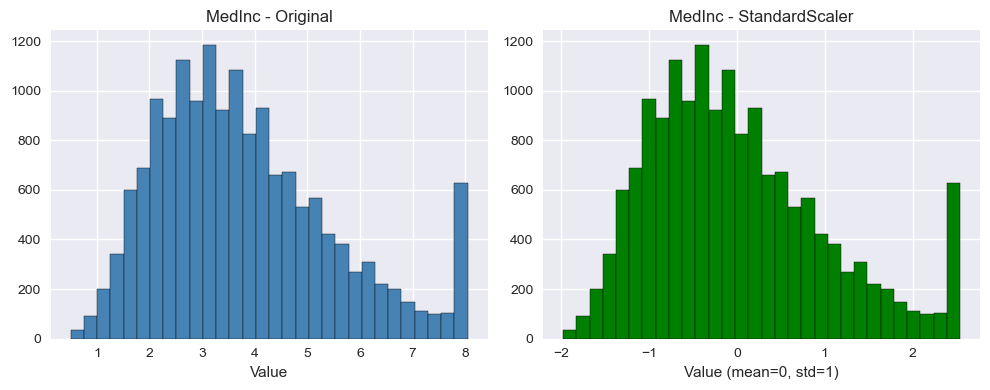

In [21]:
# Compare the two scaling methods
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

feature = 'MedInc'

axes[0].hist(X_train[feature], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title(f'{feature} - Original')
axes[0].set_xlabel('Value')

axes[1].hist(X_train_standard[feature], bins=30, color='green', edgecolor='black')
axes[1].set_title(f'{feature} - StandardScaler')
axes[1].set_xlabel('Value (mean=0, std=1)')

plt.tight_layout()
plt.show()

## 5. Feature Selection

Remove features that don't help the model. We'll use correlation analysis to check for:
1. **Low correlation with target** → feature may not be useful
2. **High correlation between features** → redundant (multicollinearity)

In [22]:
correlation_matrix = pd.concat([X_train_standard,y_train],axis=1).corr()
correlation_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,IncomeCategory,RoomsPerPerson,BedroomRatio,DistToSF,DistToLA,AgeCategory_encoded,median_house_value
MedInc,1.000000,-0.137174,0.658221,-0.221886,-0.002282,-0.070165,-0.084288,-0.015793,0.946511,0.471176,-0.640469,-0.023377,-0.067401,-0.128596,0.691857
HouseAge,-0.137174,1.000000,-0.230072,-0.128656,-0.298733,-0.003837,0.005568,-0.103021,-0.127523,-0.137325,0.164163,-0.097582,-0.036927,0.870048,0.105821
AveRooms,0.658221,-0.230072,1.000000,0.174137,-0.099875,-0.040671,0.131109,-0.071456,0.624381,0.700672,-0.885645,-0.083790,0.152685,-0.213770,0.314524
AveBedrms,-0.221886,-0.128656,0.174137,1.000000,0.004608,-0.114226,0.064515,0.010003,-0.206965,0.236637,0.140486,0.017447,0.070795,-0.143077,-0.098091
Population,-0.002282,-0.298733,-0.099875,0.004608,1.000000,0.228535,-0.133308,0.118144,-0.004207,-0.239607,0.104764,0.105675,-0.138244,-0.271052,-0.035938
AveOccup,-0.070165,-0.003837,-0.040671,-0.114226,0.228535,1.000000,-0.169769,0.177767,-0.062044,-0.691883,0.015341,0.154608,-0.211330,0.042288,-0.279587
Latitude,-0.084288,0.005568,0.131109,0.064515,-0.133308,-0.169769,1.000000,-0.924640,-0.077879,0.189176,-0.136190,-0.898018,0.941632,-0.025098,-0.143751
Longitude,-0.015793,-0.103021,-0.071456,0.010003,0.118144,0.177767,-0.924640,1.000000,-0.015601,-0.151797,0.094522,0.954635,-0.892450,-0.053933,-0.044926
IncomeCategory,0.946511,-0.127523,0.624381,-0.206965,-0.004207,-0.062044,-0.077879,-0.015601,1.000000,0.445150,-0.601336,-0.021994,-0.062866,-0.119141,0.658672
RoomsPerPerson,0.471176,-0.137325,0.700672,0.236637,-0.239607,-0.691883,0.189176,-0.151797,0.445150,1.000000,-0.591626,-0.144574,0.232451,-0.157969,0.412652


In [23]:
print("Correlations with Target (median_house_value):")
correlations = correlation_matrix['median_house_value'].abs().sort_values(ascending=False)
correlations = correlations.drop('median_house_value')
correlations

Correlations with Target (median_house_value):


MedInc                 0.691857
IncomeCategory         0.658672
RoomsPerPerson         0.412652
AveRooms               0.314524
AveOccup               0.279587
BedroomRatio           0.248038
Latitude               0.143751
DistToLA               0.129513
HouseAge               0.105821
AveBedrms              0.098091
AgeCategory_encoded    0.061077
Longitude              0.044926
Population             0.035938
DistToSF               0.028625
Name: median_house_value, dtype: float64

In [24]:
print('Top 10 features correlated with target:')
print(correlations.head(10).round(4))
print(f'\nBottom 5:')
print(correlations.tail(5).round(4))

Top 10 features correlated with target:
MedInc            0.6919
IncomeCategory    0.6587
RoomsPerPerson    0.4127
AveRooms          0.3145
AveOccup          0.2796
BedroomRatio      0.2480
Latitude          0.1438
DistToLA          0.1295
HouseAge          0.1058
AveBedrms         0.0981
Name: median_house_value, dtype: float64

Bottom 5:
AveBedrms              0.0981
AgeCategory_encoded    0.0611
Longitude              0.0449
Population             0.0359
DistToSF               0.0286
Name: median_house_value, dtype: float64


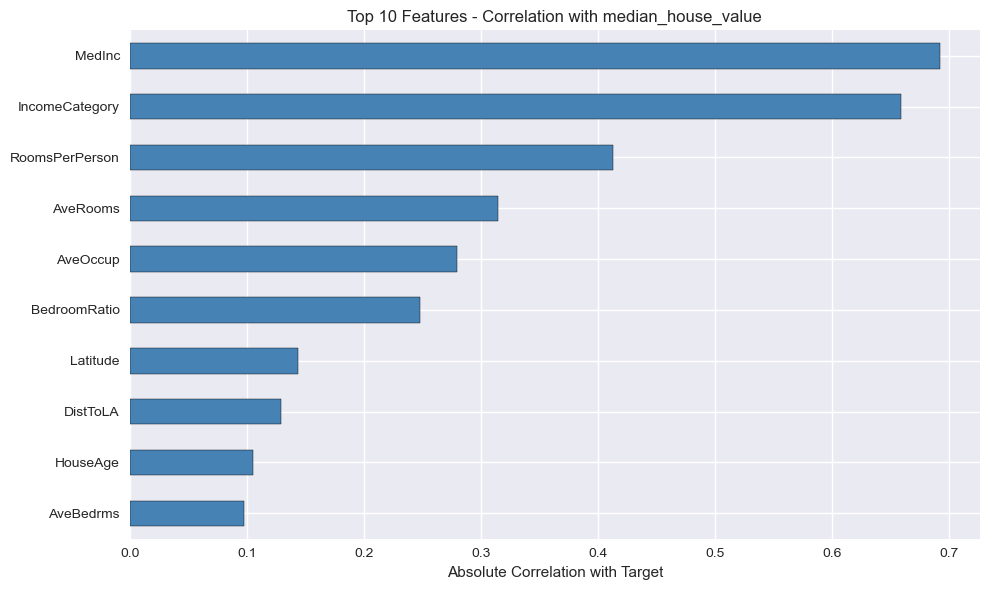

In [25]:
## visualize top 10 feature correlations with target

top10 = correlations.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh', color='steelblue',edgecolor='black')
plt.xlabel('Absolute Correlation with Target')
plt.title('Top 10 Features - Correlation with median_house_value')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [26]:
len(X_train.columns)

16

In [28]:
# find pairs with absolute correlation > 0.8
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range (i+1, len(correlation_matrix.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.8:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))

In [29]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print("Highly correlated feature pairs (>0.8):")
high_corr_df

Highly correlated feature pairs (>0.8):


,Feature 1,Feature 2,Correlation
0,Longitude,DistToSF,0.954635
1,MedInc,IncomeCategory,0.946511
2,Latitude,DistToLA,0.941632
3,HouseAge,AgeCategory_encoded,0.870048
4,DistToSF,DistToLA,-0.849121
5,AveRooms,BedroomRatio,-0.885645
6,Longitude,DistToLA,-0.892450
7,Latitude,DistToSF,-0.898018
8,Latitude,Longitude,-0.924640


In [30]:
high_corr_df.sort_values(by='Feature 1')

,Feature 1,Feature 2,Correlation
5,AveRooms,BedroomRatio,-0.885645
4,DistToSF,DistToLA,-0.849121
3,HouseAge,AgeCategory_encoded,0.870048
2,Latitude,DistToLA,0.941632
7,Latitude,DistToSF,-0.898018
8,Latitude,Longitude,-0.924640
0,Longitude,DistToSF,0.954635
6,Longitude,DistToLA,-0.892450
1,MedInc,IncomeCategory,0.946511


## 6. Save Final Data for Modeling

We save **two versions** of training data:
- **unscaled data** — for tree models
- **scaled data** - for linear models

In [31]:
import os

os.makedirs('../data/modeling', exist_ok=True)

# Save unscaled (for tree models)
X_train.to_csv('../data/modeling/X_train.csv', index=False)
X_test.to_csv('../data/modeling/X_test.csv', index=False)
y_train.to_csv('../data/modeling/y_train.csv', index=False)
y_test.to_csv('../data/modeling/y_test.csv', index=False)


# Save scaled (for linear models)
X_train_standard.to_csv('../data/modeling/X_train_standard.csv', index=False)
X_test_standard.to_csv('../data/modeling/x_test_standard.csv', index=False)


print("Data saved!")
print(f"  train_engineered.csv: {X_train.shape[1]} columns (unscaled)")
print(f"  train_scaled.csv: {X_train_standard.shape[1]} columns (scaled)")

Data saved!
  train_engineered.csv: 16 columns (unscaled)
  train_scaled.csv: 14 columns (scaled)


## Summary

### Feature Created:

- 
### Processing Applied:
- Ordinal encoded: 
- One-hot encoded: 
- Scaled: all numerical features

### Datasets:
- **X_train/y_train** original unscaled dataset
- **X_train_standard/y_train_standard** scaled dataset for linear models
- **X_test/y_test** untouched test sets for final evaluation